In [1]:
import os
import torch

from datasets import load_dataset

from transformers.utils.import_utils import is_flash_attn_2_available

from colpali_engine.models import ColQwen2, ColQwen2Processor
#from colpali_engine.models import ColPali, ColPaliProcessor # uncomment if you prefer to use ColPali models instead of ColQwen2 models


import base64
from io import BytesIO

import matplotlib.pyplot as plt

from colpali_engine.interpretability import (
    get_similarity_maps_from_embeddings,
    plot_similarity_map,
)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# colpali inference wrapper

# Get rid of process forking deadlock warnings.
os.environ["TOKENIZERS_PARALLELISM"] = "false"

if torch.cuda.is_available(): # If GPU available
    device = "cuda:0"
elif torch.backends.mps.is_available(): # If Apple Silicon available
    device = "mps"
else:
    device = "cpu"

if is_flash_attn_2_available():
    attn_implementation = "flash_attention_2"
else:
    attn_implementation = "eager"

print(f"Using device: {device}")
print(f"Using attention implementation: {attn_implementation}")

model_name = "vidore/colqwen2-v1.0"

# About a 5 GB download and similar memory usage.
model = ColQwen2.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map=device,
    attn_implementation=attn_implementation,
).eval()

# Load processor
processor = ColQwen2Processor.from_pretrained(model_name)

# A convenience class to wrap the embedding functionality 
# of ColVision models like ColPali and ColQwen2 
class ColVision:
    def __init__(self, model, processor):
        """Initialize with a loaded model and processor."""
        self.model = model
        self.processor = processor

    # A batch size of one appears to be most performant when running on an M4.
    # Note: Reducing the image resolution speeds up the vectorizer and produces
    # fewer multi-vectors.
    def multi_vectorize_image(self, img):
        """Return the multi-vector image of the supplied PIL image."""
        image_batch = self.processor.process_images([img]).to(self.model.device)
        with torch.no_grad():
            image_embedding = self.model(**image_batch)
        return image_embedding[0]

    def multi_vectorize_text(self, query):
        """Return the multi-vector embedding of the query text string."""
        query_batch = self.processor.process_queries([query]).to(self.model.device)
        with torch.no_grad():
            query_embedding = self.model(**query_batch)
        return query_embedding[0]

# Instantiate the model to be used below.
colvision_embedder = ColVision(model, processor) # This will be instantiated after loading the model and processor

`torch_dtype` is deprecated! Use `dtype` instead!


Using device: mps
Using attention implementation: eager


Loading checkpoint shards: 100%|██████████| 2/2 [00:10<00:00,  5.45s/it]
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


In [3]:
queries = load_dataset("weaviate/irpapers-queries")["train"]

In [25]:
queries[100]

{'dataset_id': '13_7',
 'pdf_id': 13,
 'pdf_title': 'RaFe: Ranking Feedback Improves Query Rewriting for RAG',
 'page_number': 7,
 'question': 'What three categories does RaFe identify for how query rewriting improvements occur based on case studies?',
 'answer': 'RaFe identifies three improvement types: preserving the semantics of the original query, improving the format for retrieval purposes, and rewriting sentences for better understanding by the retrieval system.'}

In [26]:
query = queries[100]["question"]

In [12]:
docs = load_dataset("weaviate/irpapers-docs")["train"]

In [13]:
docs = docs.to_list()

In [27]:
target = next(doc for doc in docs if doc.get("dataset_id") == "13_7")

In [28]:
import PIL

image = PIL.Image.open(BytesIO(base64.b64decode(target["base64_str"])))

Similarity map shape: (query_length, n_patches_x, n_patches_y) = (28, 23, 32)


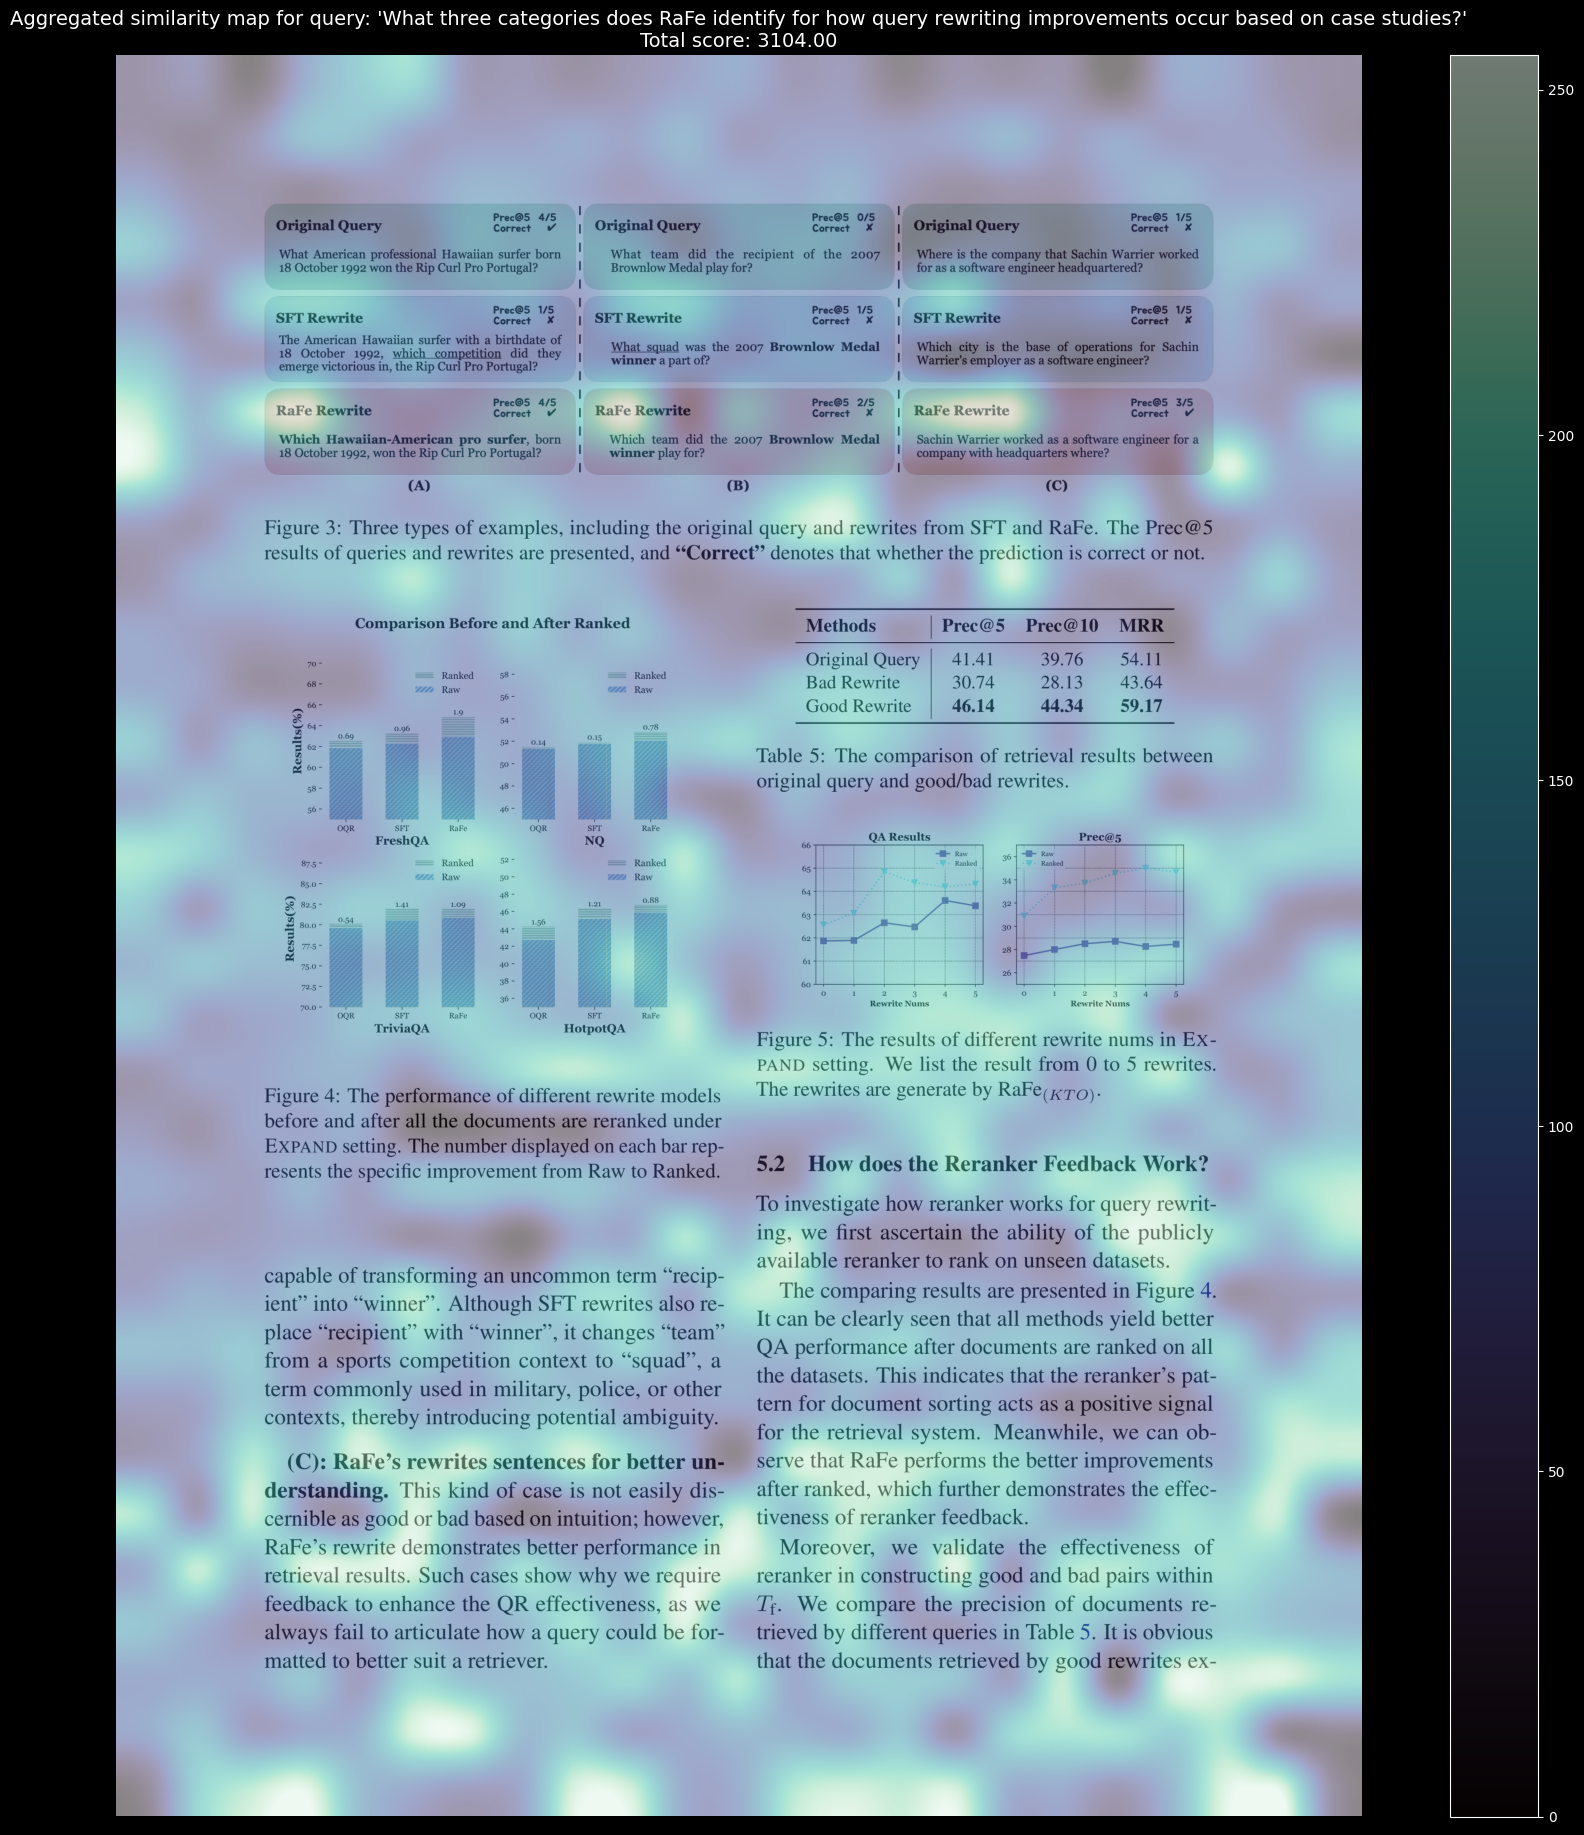

In [29]:
# Preprocess inputs
batch_images = processor.process_images([image]).to(device)
batch_queries = processor.process_queries([query]).to(device)

# Forward passes
with torch.no_grad():
    image_embeddings = model.forward(**batch_images)
    query_embeddings = model.forward(**batch_queries)

# Get the number of image patches
n_patches = processor.get_n_patches(
    image_size=image.size,
    spatial_merge_size=model.spatial_merge_size,
)

# Get the tensor mask to filter out the embeddings that are not related to the image
image_mask = processor.get_image_mask(batch_images)

# Generate the similarity maps
batched_similarity_maps = get_similarity_maps_from_embeddings(
    image_embeddings=image_embeddings,
    query_embeddings=query_embeddings,
    n_patches=n_patches,
    image_mask=image_mask,
)

# Get the similarity map for our (only) input image
similarity_maps = batched_similarity_maps[0]  # (query_length, n_patches_x, n_patches_y)

print(f"Similarity map shape: (query_length, n_patches_x, n_patches_y) = {tuple(similarity_maps.shape)}")

# Remove the padding tokens and the query augmentation tokens
query_content = processor.decode(batch_queries.input_ids[0])
query_content = query_content.replace(processor.tokenizer.pad_token, "")
query_content = query_content.replace(processor.query_augmentation_token, "").strip()

# Retokenize the cleaned query
query_tokens = processor.tokenizer.tokenize(query_content)

# Sum over all query tokens (or just the content tokens)
# Option 1: Sum over all tokens in similarity_maps
aggregated_similarity_map = similarity_maps.sum(dim=0)  # (n_patches_x, n_patches_y)

# Option 2: Sum only over the actual query content tokens (excluding padding/augmentation)
# aggregated_similarity_map = similarity_maps[:len(query_tokens)].sum(dim=0)

# Option 3: Use max instead of sum (takes the max similarity across all tokens per patch)
# aggregated_similarity_map = similarity_maps[:len(query_tokens)].max(dim=0).values

fig, ax = plot_similarity_map(
    image=image,
    similarity_map=aggregated_similarity_map,
    figsize=(18, 18),
    show_colorbar=True,  # Colorbar can be helpful for aggregated maps
)

total_score = aggregated_similarity_map.sum().item()
ax.set_title(f"Aggregated similarity map for query: '{query_content}'\nTotal score: {total_score:.2f}", fontsize=14)

plt.savefig("aggregated_similarity_map.png")
plt.show()